In [ ]:
# --timeframe 1d   : Таймфрейм свечей (дневные данные).
# --start-year 2000: Глубина загрузки истории (начиная с 2000 года).
# --workers 6      : Количество параллельных потоков для ускорения загрузки.

!python -m _tools.update_market_data --timeframe 1d --start-year 2000 --workers 18
!python -m _tools.update_macro --timeframe 1d --start-year 2000 --workers 18
# Выполняет комплексную проверку целостности, отсутствия пропусков и корректности OHLCV данных.
!python -m _tools.check_data_quality

In [ ]:
!bash start_data_swarm.sh

In [ ]:
!bash stop_data_swarm.sh

In [ ]:
!python -m _tools.check_and_heal_data

In [ ]:
#полная проверка подготовленных на предыдущем этапе данных
!python -m _tools.verify_data

In [ ]:
#Запуск нескольких процессов в параллели
!bash start_swarm.sh \
    --dataset_dir "data/processed/2000_2026_1d_18_3" \
    --bonus_ratio 0.2 \
    --min_delta 0.001 \
    --runs 400 --epochs 100 \
    --lr 2e-3 --l2_reg 1e-5 \
    --start_fold "fold_2013" \
    --factor 0.5 --patience 3 \
    --vram 10000/8 --stagger 0 \
    --keep 5 \
    --append \
    --arch mlp
    #--arch cnn, conv1d+gru, mlp, attention
    #--track_trajectory
    #--init_pca_coord -148.0 -116.0 --init_pca_radius 20.0 \

In [1]:
!./stop_swarm.sh
!python -m _tools.clean_lstm_models --keep 5

In [ ]:
#python run_all_ensembles.py --dataset_dir "data/processed/2000_2026_1d_10_1" --max_k 20
import os
from pathlib import Path
DATASET_DIR = "data/processed/2000_2026_1d_5_10"
MAX_K = 20
folds = sorted([d.name for d in Path(DATASET_DIR).glob("fold_*") if d.is_dir()])
print(f"🔍 Найдено фолдов: {len(folds)} в конфигурации {DATASET_DIR}\n")
for fold in folds:
    print("\n" + "="*80)
    print(f"🚀 ЗАПУСК АНСАМБЛИРОВАНИЯ: {fold}")
    print("="*80)
    !python -m _tools.ensemble_predictor --dataset_dir {DATASET_DIR} --fold {fold} --max_k {MAX_K}

In [ ]:
%run _tools/plot_landscape.py --fold data/processed/2000_2026_1d_30_5/fold_2014

In [ ]:
%matplotlib inline
%run _tools/analyze_runs.py data/processed/2000_2026_1d_3_1/fold_2026 --runs 100 --arch attention

In [ ]:
!python -m _tools.prepare_rl_env

In [ ]:
!python -m _tools.check_env_data

In [ ]:
!python -m _tools.train_rllib_pbt --population 6 --iterations 300 --force
#--cpu

In [ ]:
# Запуск отчета
report = generate_report("data/processed")
display(report)

In [ ]:
%load_ext tensorboard
%tensorboard --logdir data/processed/2000_2026_1d/rl_env/ray_results/pbt_trading_bot

In [34]:
from pathlib import Path

def print_tree(directory, prefix=""):
    """Рекурсивный вывод структуры папок и файлов"""
    dir_path = Path(directory)
    if not dir_path.exists():
        print(f"❌ Путь не найден: {directory}")
        return

    # Получаем список всех элементов и сортируем
    items = sorted(list(dir_path.iterdir()), key=lambda x: (not x.is_dir(), x.name))
    
    for i, item in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        print(f"{prefix}{connector}{item.name}")
        
        if item.is_dir():
            # Если это папка, заходим в неё (но ограничиваем глубину для чистоты, если нужно)
            extension = "    " if is_last else "│   "
            print_tree(item, prefix + extension)

# Путь к папке
target_path = "/home/restorator/trader_test/data/processed/2000_2026_1d/rl_env"

print(f"🌲 Структура проекта для: {target_path}")
print_tree(target_path)

🌲 Структура проекта для: /home/restorator/trader_test/data/processed/2000_2026_1d/rl_env
├── champions
│   ├── fold_2010_c10_cnn_loss_0.8462_acc_70.92_run_s_03_194634_3d4714.keras
│   ├── fold_2010_c10_conv1d+gru_loss_0.8331_acc_69.53_run_s_01_203728_d0f880.keras
│   ├── fold_2010_c18_attention_loss_0.9249_acc_65.39_run_s_09_230321_cf9fae.keras
│   ├── fold_2010_c18_cnn_loss_0.9059_acc_66.45_run_s_08_071344_8b0bd8.keras
│   ├── fold_2010_c18_cnn_loss_0.9087_acc_66.28_run_s_08_071344_7b9350.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8892_acc_66.39_run_s_08_235228_c58866.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8954_acc_66.41_run_s_08_235228_658f36.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8964_acc_66.73_run_s_08_235228_40b693.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8970_acc_65.72_run_s_08_235228_40dbce.keras
│   ├── fold_2010_c18_conv1d+gru_loss_0.8992_acc_65.31_run_s_08_235228_47b87d.keras
│   ├── fold_2010_c3_mlp_loss_0.8784_acc_69.46_run_manual_a9f055.keras
│   ├── 

/tmp/ipykernel_3442431/2587581953.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


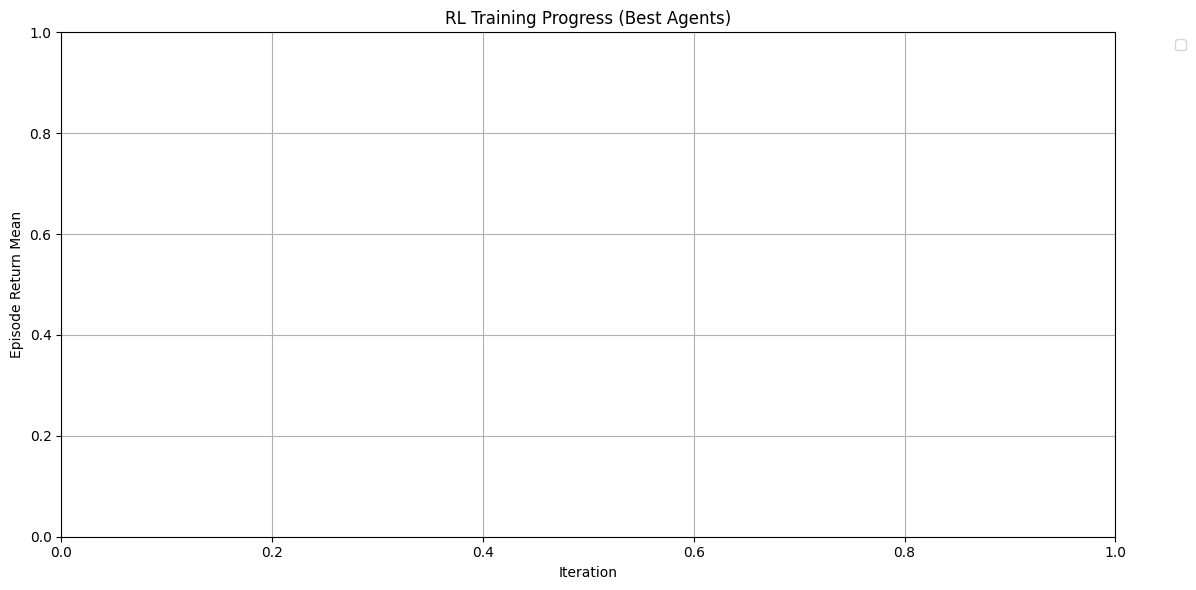

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Путь к результатам
log_dir = Path("/home/restorator/trader_test/data/processed/2000_2026_1d/rl_env/ray_results/pbt_trading_bot")
all_files = list(log_dir.rglob("progress.csv"))

plt.figure(figsize=(12, 6))

for file in all_files:
    df = pd.read_csv(file)
    # В Ray RLlib метрики часто лежат глубже. 
    # Попробуем взять самую важную колонку
    if 'env_runners/episode_return_mean' in df.columns:
        plt.plot(df['training_iteration'], df['env_runners/episode_return_mean'], label=file.parent.name)

plt.title("RL Training Progress (Best Agents)")
plt.xlabel("Iteration")
plt.ylabel("Episode Return Mean")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()